In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, recall_score, precision_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import get_linear_schedule_with_warmup

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sb
import itertools

import warnings
warnings.filterwarnings('ignore')

In [2]:
classifiers = {
    # "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    # "SVM": SVC(),
    # "C Adj SVM": SVC(C=100),
    # "Gaussian Naive Bayes": GaussianNB(),
     "Bernoulli Naive Bayes": BernoulliNB(),
    # "Logistic Regression": LogisticRegression(),
    # "SGDClassifier": SGDClassifier(),
    # "Random Forest": RandomForestClassifier(),
    # "AdaBoost": AdaBoostClassifier(),
    # "Multi Layer Perceptron": MLPClassifier(),
    # "Agglomerative Clustering": AgglomerativeClustering()
}

In [3]:
class Multi_Attention(nn.Module):
    def __init__(self, samp_model, num_heads):
        super(Multi_Attention, self).__init__()
        assert samp_model % num_heads == 0

        self.samp_model = samp_model
        self.num_heads = num_heads
        self.count = samp_model // num_heads

        self.Wq = nn.Linear(samp_model, samp_model)
        self.Wk = nn.Linear(samp_model, samp_model)
        self.Wv = nn.Linear(samp_model, samp_model)
        self.Wo = nn.Linear(samp_model, samp_model)

    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        Q, K, V = self.split_heads(Q, K, V)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.count)
        attention_weights = torch.softmax(scores, dim=-1)
        attended_values = torch.matmul(attention_weights, V)
        attended_values = self.combine_heads(attended_values)

        return self.Wo(attended_values).squeeze(1)

    def split_heads(self, Q, K, V):
        batch_size = Q.size(0)
        Q = Q.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.count).transpose(1, 2)
        return Q, K, V

    def combine_heads(self, attended_values):
        batch_size = attended_values.size(0)
        return attended_values.transpose(1, 2).contiguous().view(batch_size, -1, self.samp_model)
    
class CreditCardFraudModel(nn.Module):
    def __init__(self, input_size, dropout_prob=0.5):
        super(CreditCardFraudModel, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(128)
        )

        self.multi_attention = Multi_Attention(128, 2)
        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(64)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.BatchNorm1d(32),
        )
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.multi_attention(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output_layer(x)
        return torch.sigmoid(x)
    
def train_and_evaluate(model, train_loader, test_loader, num_epochs, optimizer, scheduler, criterion, device):
    model.train()

    for epoch in range(num_epochs):
        running_loss_avg = 0.0
        alpha = 0.1
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            running_loss_avg = alpha * loss.item() + (1 - alpha) * running_loss_avg

        # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss_avg / len(train_loader):.4f}")

    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_pred.extend(outputs.squeeze().tolist())
            y_true.extend(labels.tolist())

    y_pred = np.array(y_pred)
    y_pred_labels = (y_pred >= 0.5).astype(int)

    # This is for accuracy
    correct = np.sum(y_true == y_pred_labels)
    total = len(y_true)
    accuracy = correct / total

    precision = precision_score(y_true, y_pred_labels)
    recall = recall_score(y_true, y_pred_labels)
    f1 = f1_score(y_true, y_pred_labels)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    conf_mat = confusion_matrix(y_true, y_pred_labels)

    return precision, recall, f1, roc_auc, accuracy, conf_mat, running_loss_avg

def plot_confusion_matrix(ax, conf_mat, split, name):
    im = ax.imshow(conf_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'{name} (Split {split})')
    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(['Non-Fraud', 'Fraud'], rotation=45)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(['Non-Fraud', 'Fraud'])
    thresh = conf_mat.max() / 2.
    for i, j in itertools.product(range(conf_mat.shape[0]), range(conf_mat.shape[1])):
        ax.text(j, i, format(conf_mat[i, j], 'd'), horizontalalignment="center", color="white" if conf_mat[i, j] > thresh else "black")
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

In [4]:
def main(X, y):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    #  device = torch.device("cuda")
    skf = StratifiedKFold(n_splits=4)
    criterion = nn.BCELoss()
    
    metrics = {}
    
    for name in classifiers.keys():
        metrics[name] = {"accuracy": [], "loss": []}
        metrics["CreditCardFraudModel"] = {"accuracy": [], "loss": []}
    
    num_splits = 4
    num_classifiers = len(classifiers) + 1  # Add 1 for the CreditCardFraudModel
    fig, axes = plt.subplots(num_splits, num_classifiers, figsize=(15, 15))
    fig.tight_layout(pad=5.0)
    
    counter=1
    
    for train_index, test_index in skf.split(X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
        col_idx = 0
    
        print("This is Split number: ",counter)
    
        print("\n===========================================================================\n")
    
        for name, clf in classifiers.items():
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc_auc = roc_auc_score(y_test, y_pred)
            metrics[name]["accuracy"].append(accuracy)
        
            conf_mat = confusion_matrix(y_test, y_pred)
            plot_confusion_matrix(axes[counter - 1, col_idx], conf_mat, counter, name)
            col_idx += 1
        
            print(f"{name}:")
            print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")
    
        train_dataset = TensorDataset(torch.tensor(X_train.to_numpy(), dtype=torch.float32), torch.tensor(y_train.to_numpy(), dtype=torch.long))
        test_dataset = TensorDataset(torch.tensor(X_test.to_numpy(), dtype=torch.float32), torch.tensor(y_test.to_numpy(), dtype=torch.long))
    
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
        model = CreditCardFraudModel(X_train.shape[1]).to(device)
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
        num_epochs = 15
        num_train_steps = num_epochs * len(train_loader)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * num_train_steps), num_training_steps=num_train_steps)
    
        precision, recall, f1, roc_auc, accuracy, conf_mat, running_loss_avg = train_and_evaluate(model, train_loader, test_loader, num_epochs, optimizer, scheduler, criterion, device)
        
    
        metrics["CreditCardFraudModel"]["accuracy"].append(accuracy)
        running_loss_avg = running_loss_avg / len(train_loader)
        metrics["CreditCardFraudModel"]["loss"].append(running_loss_avg)
    
        plot_confusion_matrix(axes[counter - 1, col_idx], conf_mat, counter, "CreditCardFraudModel")
        
        print("\n===========================================================================\n")
        print("For the CreditCardFraudModel:")
        print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
        print("\n===========================================================================\n")
        
        counter+=1
    
    print("\nAll the Confusion Matrices:")
    plt.show()


In [5]:
df = pd.read_csv('../Data/creditcard.csv')

In [6]:
decision_features = df.columns[:-1]
target_feature = df.columns[-1]

In [7]:
X, y = df[decision_features], df[target_feature]


In [8]:
X["Amount"]

0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64

In [14]:
X["Amount"] = StandardScaler.fit_transform(X["Amount"],y)



AttributeError: 'Series' object has no attribute 'fit'

In [13]:
X["Amount"]

0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64

In [ ]:
# main(X, y)

In [ ]:
# Equalize the number of fraudulent and non-fraudulent transactions within the dataframe

minority_count = df[df['Class'] == 1].shape[0]
majority_count = df[df['Class'] == 0].shape[0]

total_desired_rows = 5000
desired_minority_count = total_desired_rows // 2
desired_majority_count = total_desired_rows // 2

smote = SMOTE(sampling_strategy={1: desired_minority_count})
under = RandomUnderSampler(sampling_strategy={0: desired_majority_count})
pipeline = Pipeline(steps=[('s', smote), ('u', under)])
X_new, y_new = pipeline.fit_resample(X, y) 

cpu
This is Split number:  1


Bernoulli Naive Bayes:
Accuracy: 0.9370, Precision: 0.9910, Recall: 0.8820, F1-score: 0.9333, ROC-AUC: 0.9370



KeyboardInterrupt: 

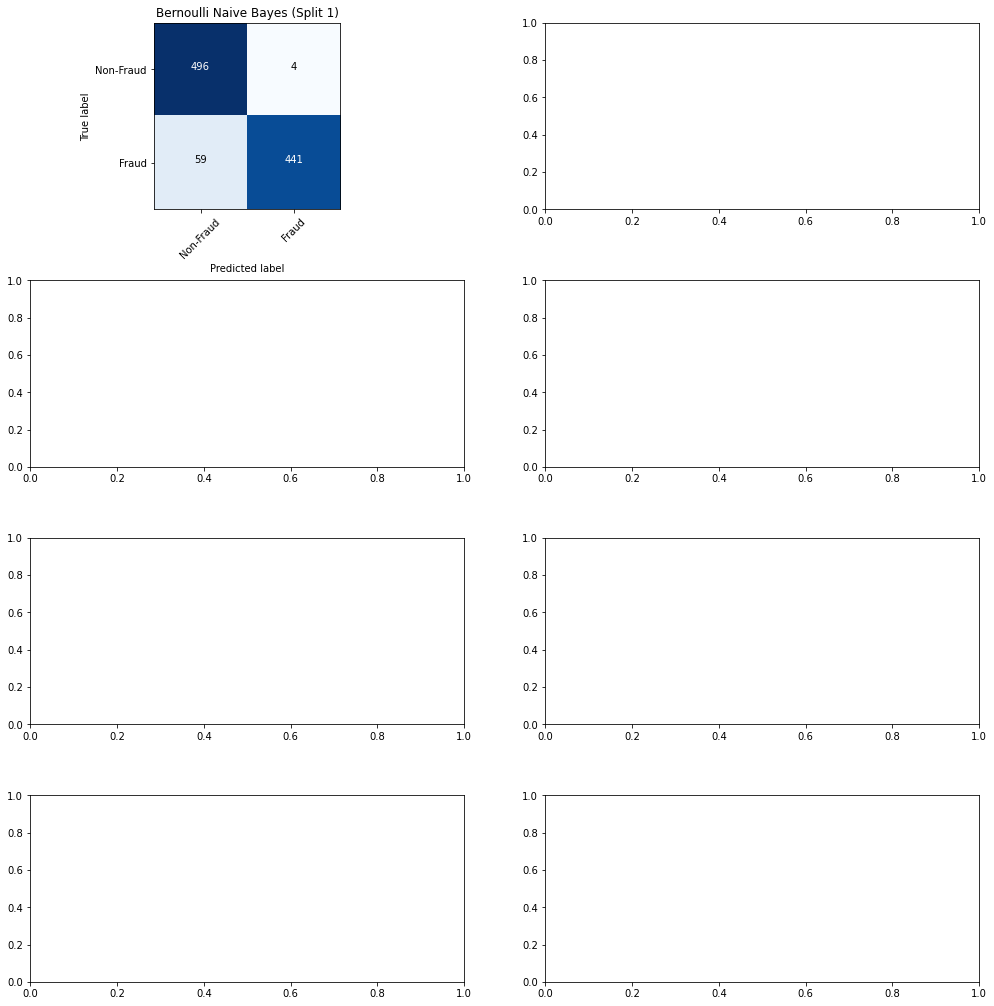

In [ ]:
main(X_new, y_new)